# GMDNN — Rede Neural Densa (MLP) para o GMD

Modelo **central do TCC**: MLP em PyTorch que prevê `gmd_kg_dia`. Pré-processamento compartilhado via `data_prep` (v3). Inclui **grid search** de hiperparâmetros (CV 10-fold), **leave-one-property-out** (robustez) e comparação com/sem **jitter** (augmentation).

## 1. Setup

In [1]:
import sys, copy
sys.path.append("support_scripts")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from itertools import product
import data_prep as dp

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(dp.SEED); np.random.seed(dp.SEED)
print("device:", device)

device: cuda


## 2. Dados (via `data_prep` v3)

In [2]:
d = dp.get_data()
df, groups = d["df"], d["groups"]
scale_cols, TARGET = d["scale_cols"], dp.TARGET
print(f"{len(df)} animais | {len(scale_cols)} preditores")
print("preditores:", scale_cols)
print("grupos:", groups.value_counts().to_dict())

155 animais | 8 preditores
preditores: ['peso_entrada_kg', 'dias_permanencia', 'media_suplemento_kg_dia', 'pb_suplemento_pct', 'media_proteina_bruta_forragem_pct', 'numero_eventos_transporte', 'temperatura_media_c', 'proporcao_ciclo_seca']
grupos: {'elvis': 94, 'sonico': 61}


## 3. Rede — `GMDNN`

Blocos Linear → BatchNorm → ReLU → Dropout; saída linear de 1 neurônio.

In [3]:
class GMDNN(nn.Module):
    def __init__(self, n_in, hidden=(64, 32), p_drop=0.1, batchnorm=True):
        super().__init__()
        layers, prev = [], n_in
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            if batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers += [nn.ReLU(), nn.Dropout(p_drop)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## 4. Treino + avaliação (por fold)

Cada chamada: separa uma validação interna do treino p/ **early stopping**, opcionalmente aplica **jitter** só no treino, escalona (fit só no treino, X e y), treina com Huber loss + LR scheduler, e avalia em `eval_df` **real** (métricas em kg/dia, predição destransformada).

In [4]:
def train_eval(train_df, eval_df, cfg, augment=False, seed=dp.SEED):
    torch.manual_seed(seed); np.random.seed(seed)
    tr_df, es_df = train_test_split(train_df, test_size=0.15, random_state=seed)
    if augment:
        tr_df = dp.augment_train(tr_df, k=cfg.get('k', 2), seed=seed)

    xs = StandardScaler().fit(tr_df[scale_cols])
    ys = StandardScaler().fit(tr_df[[TARGET]])
    def tens(dd):
        X = torch.tensor(xs.transform(dd[scale_cols]), dtype=torch.float32)
        y = torch.tensor(ys.transform(dd[[TARGET]]), dtype=torch.float32)
        return X, y
    Xtr, ytr = tens(tr_df); Xes, yes = tens(es_df)
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=32, shuffle=True, drop_last=True)

    model = GMDNN(len(scale_cols), cfg['hidden'], cfg['p_drop'], cfg['batchnorm']).to(device)
    opt = optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg.get('wd', 0.0))
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=8)
    crit = nn.SmoothL1Loss()
    Xes_d, yes_d = Xes.to(device), yes.to(device)
    best, best_state, wait = 1e9, None, 0
    for epoch in range(300):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            v = crit(model(Xes_d), yes_d).item()
        sched.step(v)
        if v < best - 1e-5:
            best, best_state, wait = v, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= 20:
                break
    model.load_state_dict(best_state)

    model.eval()
    Xe = torch.tensor(xs.transform(eval_df[scale_cols]), dtype=torch.float32).to(device)
    with torch.no_grad():
        pred = ys.inverse_transform(model(Xe).cpu().numpy()).ravel()
    return dp.metrics(eval_df[TARGET].values, pred), pred


def cv_evaluate(cfg, augment=False):
    fold_m = []
    for tr, va in dp.get_cv().split(df):
        m, _ = train_eval(df.iloc[tr], df.iloc[va], cfg, augment=augment)
        fold_m.append(m)
    return dp.summarize(fold_m)[0]

## 5. Grid search (CV 10-fold) — grade expandida

Arquitetura × dropout × **learning-rate (até 1e-2)** × BatchNorm × **weight_decay**. Seleção pela melhor R² média no CV 10-fold. A grade anterior teve ótimo nas bordas (lr máx, dropout 0, BN off), daí a expansão. (48 configs.)

In [5]:
GRID = dict(
    hidden=[(64, 32), (128, 64, 32)],
    p_drop=[0.0, 0.1],
    lr=[3e-3, 5e-3, 1e-2],
    batchnorm=[False, True],
    wd=[0.0, 1e-4],
)
keys = list(GRID)
rows = []
for vals in product(*GRID.values()):
    cfg = dict(zip(keys, vals))
    cv = cv_evaluate(cfg, augment=False)
    rows.append({**cfg, 'MAE': round(cv.MAE.mean(), 4),
                 'R2': round(cv.R2.mean(), 4), 'R2_std': round(cv.R2.std(), 3)})
    print(f"{cfg}  ->  R2={rows[-1]['R2']:.3f}  MAE={rows[-1]['MAE']:.4f}")

res = pd.DataFrame(rows).sort_values('R2', ascending=False).reset_index(drop=True)
res

{'hidden': (64, 32), 'p_drop': 0.0, 'lr': 0.003, 'batchnorm': False, 'wd': 0.0}  ->  R2=0.574  MAE=0.0370


{'hidden': (64, 32), 'p_drop': 0.0, 'lr': 0.003, 'batchnorm': False, 'wd': 0.0001}  ->  R2=0.580  MAE=0.0362


{'hidden': (64, 32), 'p_drop': 0.0, 'lr': 0.003, 'batchnorm': True, 'wd': 0.0}  ->  R2=0.529  MAE=0.0381


{'hidden': (64, 32), 'p_drop': 0.0, 'lr': 0.003, 'batchnorm': True, 'wd': 0.0001}  ->  R2=0.521  MAE=0.0387


{'hidden': (64, 32), 'p_drop': 0.0, 'lr': 0.005, 'batchnorm': False, 'wd': 0.0}  ->  R2=0.612  MAE=0.0349


...

{'hidden': (128, 64, 32), 'p_drop': 0.1, 'lr': 0.01, 'batchnorm': False, 'wd': 0.0}  ->  R2=0.562  MAE=0.0388


{'hidden': (128, 64, 32), 'p_drop': 0.1, 'lr': 0.01, 'batchnorm': False, 'wd': 0.0001}  ->  R2=0.552  MAE=0.0384


{'hidden': (128, 64, 32), 'p_drop': 0.1, 'lr': 0.01, 'batchnorm': True, 'wd': 0.0}  ->  R2=0.571  MAE=0.0360


{'hidden': (128, 64, 32), 'p_drop': 0.1, 'lr': 0.01, 'batchnorm': True, 'wd': 0.0001}  ->  R2=0.589  MAE=0.0362


,hidden,p_drop,lr,batchnorm,wd,MAE,R2,R2_std
0,"(64, 32)",0.0,0.010,False,0.0001,0.0320,0.6647,0.196
1,"(64, 32)",0.0,0.010,False,0.0000,0.0347,0.6520,0.163
2,"(128, 64, 32)",0.0,0.010,True,0.0000,0.0337,0.6449,0.152
3,"(128, 64, 32)",0.0,0.005,False,0.0001,0.0343,0.6337,0.238
4,"(128, 64, 32)",0.0,0.003,False,0.0000,0.0332,0.6333,0.183
5,"(64, 32)",0.1,0.010,True,0.0001,0.0343,0.6303,0.178
6,"(64, 32)",0.0,0.005,False,0.0001,0.0345,0.6296,0.183
7,"(128, 64, 32)",0.0,0.010,True,0.0001,0.0339,0.6178,0.184
8,"(128, 64, 32)",0.0,0.003,False,0.0001,0.0341,0.6142,0.208
9,"(64, 32)",0.0,0.005,False,0.0000,0.0349,0.6123,0.193


## 6. Melhor configuração — CV com e sem jitter

In [6]:
best = {k: res.iloc[0][k] for k in keys}
print('melhor config:', best)

cv_plain = cv_evaluate(best, augment=False)
cv_aug = cv_evaluate(best, augment=True)
tab = pd.DataFrame({
    'sem jitter': cv_plain.agg(['mean', 'std']).stack(),
    'com jitter': cv_aug.agg(['mean', 'std']).stack(),
}).round(4)
base = dp.baseline_mae(df[TARGET], df[TARGET])
print(f'baseline MAE (média): {base:.4f}')
tab

melhor config: {'hidden': (64, 32), 'p_drop': np.float64(0.0), 'lr': np.float64(0.01), 'batchnorm': np.False_, 'wd': np.float64(0.0001)}


baseline MAE (média): 0.0655


sem jitter  com jitter
mean MAE       0.0320      0.0307
     RMSE      0.0467      0.0461
     R2        0.6647      0.6897
std  MAE       0.0074      0.0087
     RMSE      0.0123      0.0135
     R2        0.1961      0.1363

## 7. Robustez — leave-one-property-out (Elvis ↔ Sonico)

In [7]:
lopo = []
for tr, te, p in dp.leave_one_property_out(groups):
    m, _ = train_eval(df.iloc[tr], df.iloc[te], best, augment=False)
    m['testa'] = p
    lopo.append(m)
lopo_df = pd.DataFrame(lopo)[['testa', 'MAE', 'RMSE', 'R2']].round(4)
print('Treina numa fazenda, testa na outra:')
lopo_df

Treina numa fazenda, testa na outra:


,testa,MAE,RMSE,R2
0,elvis,0.0694,0.0963,-0.0614
1,sonico,0.4606,0.6626,-76.3395


## 8. Predito × real (out-of-fold) e salvar resultado

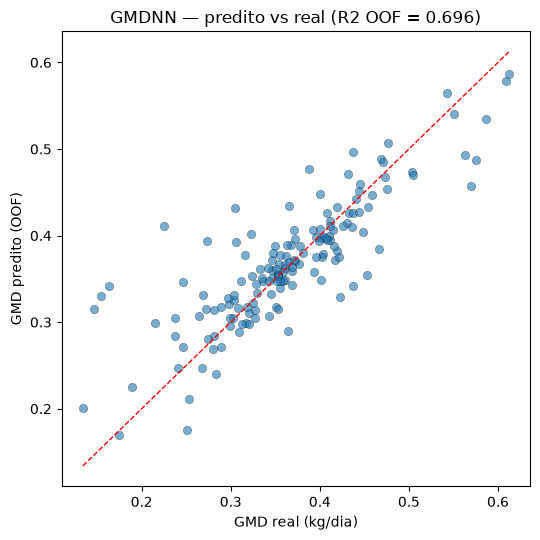

salvo em results/model_comparison.csv


In [8]:
y_true = df[TARGET].values.copy()
y_oof = np.zeros(len(df))
for tr, va in dp.get_cv().split(df):
    _, pred = train_eval(df.iloc[tr], df.iloc[va], best, augment=False)
    y_oof[va] = pred

r2_oof = dp.metrics(y_true, y_oof)['R2']
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_true, y_oof, alpha=0.6, edgecolor='k', linewidth=.3)
lims = [min(y_true.min(), y_oof.min()), max(y_true.max(), y_oof.max())]
ax.plot(lims, lims, 'r--', lw=1)
ax.set_xlabel('GMD real (kg/dia)'); ax.set_ylabel('GMD predito (OOF)')
ax.set_title(f'GMDNN — predito vs real (R2 OOF = {r2_oof:.3f})')
plt.tight_layout(); plt.show()

lopo_mean = {'MAE': lopo_df.MAE.mean(), 'R2': lopo_df.R2.mean()}
best_cv = cv_aug if cv_aug.R2.mean() > cv_plain.R2.mean() else cv_plain
dp.save_result('MLP_DNN', best_cv, ext_metrics=lopo_mean)
print('salvo em', dp.RESULTS_PATH)

## 9. Notas

- **Grid search** seleciona a config por R² média no CV 10-fold; mesmo esquema será usado nos outros modelos (comparação justa).
- **Jitter** só entra no treino de cada fold; avaliação sempre em dado real.
- **LOPO** é o teste severo de validade externa entre as 2 fazendas.
- Resultado gravado em `results/model_comparison.csv` (via `dp.save_result`).